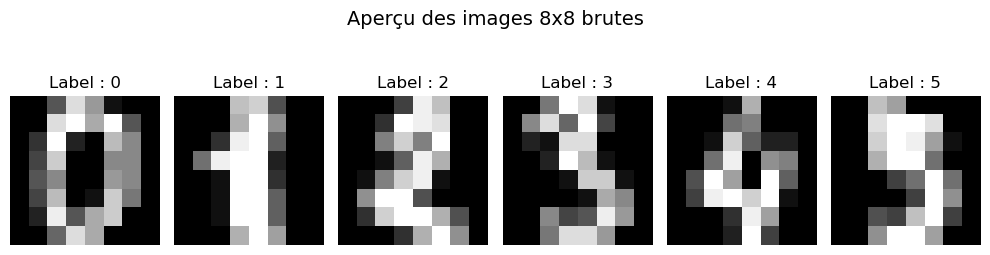

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
digits = load_digits()

plt.figure(figsize=(10, 3))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label : {digits.target[i]}")
    plt.axis('off')
plt.suptitle("Aperçu des images 8x8 brutes", fontsize=14)
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(digits.images / 16.0, digits.target, test_size=0.2, random_state=42)

c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


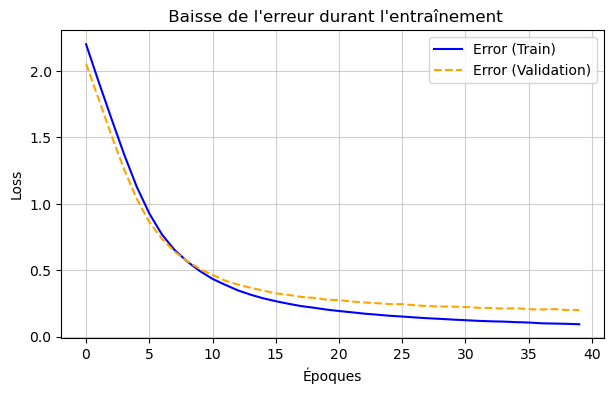

In [5]:
cifar_model= Sequential([
    Flatten(input_shape=(8,8)),
    Dense(32, activation='relu'),
    Dense(10,activation="softmax")
])

cifar_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historique = cifar_model.fit(
    X_train, y_train, 
    epochs=40, 
    validation_split=0.2, 
    verbose=0
)

plt.figure(figsize=(7, 4))
plt.plot(historique.history['loss'], label='Error (Train)', color='blue')
plt.plot(historique.history['val_loss'], label='Error (Validation)', color='orange', linestyle='--')
plt.title(" Baisse de l'erreur durant l'entraînement")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.6); plt.show()

 Précision finale sur le Test : 95.56%



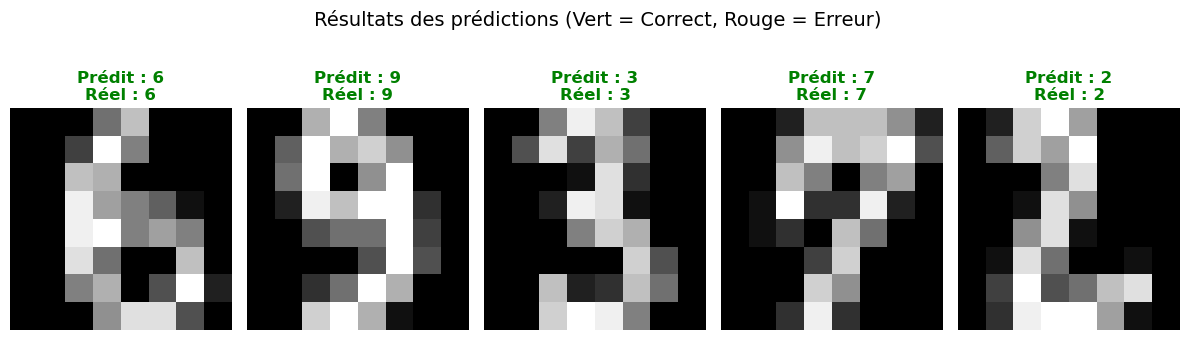

In [7]:
loss, precision = cifar_model.evaluate(X_test, y_test, verbose=0)
print(f" Précision finale sur le Test : {precision * 100:.2f}%\n")

predictions_classes = np.argmax(cifar_model.predict(X_test, verbose=0), axis=1) 

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    couleur = 'green' if predictions_classes[i] == y_test[i] else 'red'
    plt.title(f"Prédit : {predictions_classes[i]}\nRéel : {y_test[i]}", color=couleur, fontweight='bold')
    plt.axis('off')

plt.suptitle(" Résultats des prédictions (Vert = Correct, Rouge = Erreur)", fontsize=14)
plt.tight_layout(); 
plt.show()